In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

umagaba_metropt_path = kagglehub.dataset_download('umagaba/metropt')

print('Data source import complete.')


Data source import complete.


In [ ]:
import sklearn
print("scikit-learn:", sklearn.__version__)  # Must show 1.2.2


scikit-learn: 1.6.1


In [ ]:
import tensorflow as tf
#tf.keras.mixed_precision.set_global_policy('mixed_float16')
#from sklearn.ensemble import RandomForestClassifier  # Should work now

In [ ]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import shap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm, trange
import time
from tensorflow.keras.callbacks import TensorBoard, ProgbarLogger

In [ ]:
# Data Loading and Preprocessing
def load_and_preprocess_data():
    """
    Load and preprocess the dataset

    Returns:
        tuple: X_train_scaled, X_test_scaled, y_train_fault, y_test_fault, y_train_fault_type, y_test_fault_type,
               features, fault_type_mapping
    """
    print("Loading and preprocessing data...")
    # Load the dataset
    df = pd.read_csv(umagaba_metropt_path +'/MetroPT1.csv', parse_dates=['timestamp'])
    df.sort_values('timestamp', inplace=True)

    # Basic data exploration
    print("Dataset Information:")
    print(df.info())
    print("\nMissing Values:")
    print(df.isnull().sum())

    # Handle missing values
    print("Handling missing values...")
    df.fillna(df.mean(), inplace=True)

    # Feature selection and engineering
    print("Performing feature engineering...")
    failure_periods = {
        'Air leak on clients': ('2022-02-28 21:53:00', '2022-03-1 02:00:00'),
        'Air leak on air dryer': ('2022-03-23 14:54:00', '2022-03-23 15:24:00'),
        'Oil leak on compressor': ('2022-05-30 12:00:00', '2022-06-02 12:00:00')
    }

    # Create numerical labels
    fault_type_mapping = {
        0: 'No Fault',
        1: 'Air leak on clients',
        2: 'Air leak on air dryer',
        3: 'Oil leak on compressor'
    }

    df['fault'] = 0
    df['fault_type'] = 0

    for idx, (fault_name, (start, end)) in enumerate(tqdm(failure_periods.items(), desc="Labeling fault periods"), 1):
        mask = (df['timestamp'] >= pd.to_datetime(start)) & (df['timestamp'] <= pd.to_datetime(end))
        df.loc[mask, 'fault'] = 1
        df.loc[mask, 'fault_type'] = idx

    # Feature selection
    features = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs',
                'Oil_temperature', 'Motor_current', 'COMP']
    target_fault = 'fault'
    target_fault_type = 'fault_type'

    print("Splitting data into train and test sets...")
    # Extract features and targets
    X = df[features]
    y_fault = df[target_fault]
    y_fault_type = df[target_fault_type]

    # Perform random train-test split
    X_train, X_test, y_train_fault, y_test_fault, y_train_fault_type, y_test_fault_type = train_test_split(
        X, y_fault, y_fault_type, test_size=0.2, random_state=42, stratify=y_fault_type
    )

    # Scaling features
    print("Scaling features...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print("Data preprocessing completed!")
    #visualize_data(df)
    return (X_train, X_test, X_train_scaled, X_test_scaled,
            y_train_fault, y_test_fault,
            y_train_fault_type, y_test_fault_type,
            features, fault_type_mapping)

In [ ]:
#Data Visualization
def visualize_data(df):
    # Correlation matrix
    corr_matrix = df[['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs',
                    'Oil_temperature', 'Motor_current', 'COMP']].corr()
    plt.figure(figsize=(12,8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
    plt.title('Sensor Correlation Matrix')
    plt.show

    # Time-series fault visualization
    plt.figure(figsize=(15,6))
    plt.scatter(df['timestamp'], df['Oil_temperature'],
                c=df['fault_type'], cmap='viridis', alpha=0.6)
    plt.colorbar(ticks=[0,1,2,3], label='Fault Type')
    plt.title('Oil Temperature with Fault Annotations')
    plt.xlabel('Timestamp')
    plt.ylabel('Oil Temperature (°C)')
    plt.show()

    # Fault distribution visualization
    fig, ax = plt.subplots(1,2, figsize=(18,6))

    # Pie chart
    fault_counts = df['fault_type'].value_counts()
    ax[0].pie(fault_counts,
            labels=[fault_type_mapping[i] for i in fault_counts.index],
            autopct='%1.1f%%',
            startangle=90)
    ax[0].set_title('Fault Type Distribution')

In [ ]:
def random_forest_prediction(X_train, X_test, X_train_scaled, X_test_scaled,
                            y_train_fault, y_test_fault,
                            y_train_fault_type, y_test_fault_type,
                            features):
    """
    Perform Random Forest Fault Prediction and Classification

    Args:
        X_train, X_test: Original feature sets
        X_train_scaled, X_test_scaled: Scaled feature sets
        y_train_fault, y_test_fault: Fault detection labels
        y_train_fault_type, y_test_fault_type: Fault classification labels
        features: List of feature names

    Returns:
        tuple: (best_rf_fault, best_rf_fault_type, X_test_faults)
    """
    rf_start_time = time.time()

    # For simplicity, we'll use default parameters instead of GridSearchCV
    # Fault Detection Model
    rf_fault = RandomForestClassifier(random_state=42, verbose=2)

    print("Training Random Forest for fault detection...")
    with tqdm(total=100, desc="RF Fault Detection") as pbar:
        rf_fault.fit(X_train_scaled, y_train_fault)
        pbar.update(100)


    # Predict on test set
    print("Predicting on test set...")
    y_pred_fault = rf_fault.predict(X_test_scaled)

    # Evaluate the model
    print("Fault Detection - Classification Report:")
    print(classification_report(y_test_fault, y_pred_fault))

    # Confusion Matrix
    cm_fault = confusion_matrix(y_test_fault, y_pred_fault)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_fault, annot=True, fmt='d', cmap='Blues')
    plt.title('Fault Detection - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # Filter instances where a fault was detected for training fault classifier
    print("Filtering instances for fault classification...")
    fault_train_indices = np.where(y_train_fault == 1)[0]
    X_train_faults = X_train.iloc[fault_train_indices]
    X_train_faults_scaled = X_train_scaled[fault_train_indices]
    y_train_fault_type_filtered = y_train_fault_type.iloc[fault_train_indices]

    # Filter test instances where a fault was predicted
    fault_test_indices = np.where(y_pred_fault == 1)[0]
    X_test_faults = X_test.iloc[fault_test_indices]
    X_test_faults_scaled = X_test_scaled[fault_test_indices]
    y_test_fault_type_filtered = y_test_fault_type.iloc[fault_test_indices]

    # Skip fault classification if no faults were detected
    if len(fault_train_indices) == 0 or len(fault_test_indices) == 0:
        print("Not enough fault instances for classification. Skipping fault type classification.")
        return rf_fault, None, X_test, X_test_scaled, None, None

    # Fault Classification Model
    rf_fault_type = RandomForestClassifier(random_state=42, verbose=2)

    print(f"Training Random Forest for fault classification (on {len(X_train_faults_scaled)} fault instances)...")

    with tqdm(total=100, desc="RF Fault Classification") as pbar:
        rf_fault_type.fit(X_train_faults_scaled, y_train_fault_type_filtered)
        pbar.update(100)

    # Predict fault types on the filtered test set
    print("Predicting fault types...")
    y_pred_fault_type = rf_fault_type.predict(X_test_faults_scaled)

    # Evaluate the model if we have predictions
    if len(y_test_fault_type_filtered) > 0:
        print("Fault Classification - Classification Report:")
        print(classification_report(y_test_fault_type_filtered, y_pred_fault_type))

        # Confusion Matrix
        cm_fault_type = confusion_matrix(y_test_fault_type_filtered, y_pred_fault_type)
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm_fault_type, annot=True, fmt='d', cmap='Greens')
        plt.title('Fault Classification - Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()
        plt.show()

    return rf_fault, rf_fault_type, X_test, X_test_scaled, X_test_faults, X_test_faults_scaled

In [ ]:
# SHAP Root Cause Analysis
def shap_root_cause_analysis(model, X_data, feature_names, class_names=None):
    """
    Perform Root Cause Analysis using SHAP for a Random Forest model.

    Args:
        model (RandomForestClassifier): Trained Random Forest model.
        X_data (DataFrame or array): Feature data for SHAP analysis.
        feature_names (list): List of feature names.
        class_names (list, optional): List of class names for multiclass classification.
    """
    if model is None:
        print("No model provided for SHAP analysis. Skipping.")
        return


    # Create SHAP explainer
    print("Creating SHAP explainer...")
    explainer = shap.TreeExplainer(model)

    print("Calculating SHAP values...")
    with tqdm(total=100, desc="SHAP Analysis") as pbar:
        shap_values = explainer.shap_values(X_data)
        pbar.update(100)


    # Determine if the problem is binary or multiclass classification
    if isinstance(shap_values, list):
        # Multiclass classification
        num_classes = len(shap_values)
        if class_names is None:
            class_names = [f"Class {i}" for i in range(num_classes)]

        plt.figure(figsize=(12, 8))
        for i in range(min(num_classes, len(class_names))):
            plt.subplot(1, num_classes, i+1)
            shap.summary_plot(shap_values[i], X_data, feature_names=feature_names,
                             show=False, plot_size=(6, 4))
            plt.title(f'SHAP Summary - {class_names[i]}')
        plt.tight_layout()
        plt.show()
    else:
        # Binary classification
        shap.summary_plot(shap_values, X_data, feature_names=feature_names)
        plt.title('SHAP Summary Plot - Binary Classification')
        plt.tight_layout()
        plt.show()

In [ ]:
# 1. Data Preprocessing
(X_train, X_test, X_train_scaled, X_test_scaled,
y_train_fault, y_test_fault,
y_train_fault_type, y_test_fault_type,
features, fault_type_mapping) = load_and_preprocess_data()

Loading and preprocessing data...
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10773588 entries, 0 to 10773587
Data columns (total 21 columns):
 #   Column           Dtype         
---  ------           -----         
 0   timestamp        datetime64[ns]
 1   TP2              float64       
 2   TP3              float64       
 3   H1               float64       
 4   DV_pressure      float64       
 5   Reservoirs       float64       
 6   Oil_temperature  float64       
 7   Flowmeter        float64       
 8   Motor_current    float64       
 9   COMP             int64         
 10  DV_eletric       int64         
 11  Towers           int64         
 12  MPG              int64         
 13  LPS              int64         
 14  Pressure_switch  int64         
 15  Oil_level        int64         
 16  Caudal_impulses  int64         
 17  gpsLong          float64       
 18  gpsLat           float64       
 19  gpsSpeed         int64         
 20  gpsQuality 

Labeling fault periods: 100%|██████████| 3/3 [00:00<00:00, 11.74it/s]


Splitting data into train and test sets...
Scaling features...
Data preprocessing completed!


Training Random Forest for fault detection...


RF Fault Detection:   0%|          | 0/100 [00:00<?, ?it/s]

building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100


[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed: 11.6min


building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81 of 100
building tree 82

[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed: 27.5min finished
RF Fault Detection: 100%|██████████| 100/100 [27:31<00:00, 16.51s/it]


Predicting on test set...


[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:   20.2s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:   49.9s finished


Fault Detection - Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99   2108193
           1       0.88      0.38      0.53     46525

    accuracy                           0.99   2154718
   macro avg       0.93      0.69      0.76   2154718
weighted avg       0.98      0.99      0.98   2154718



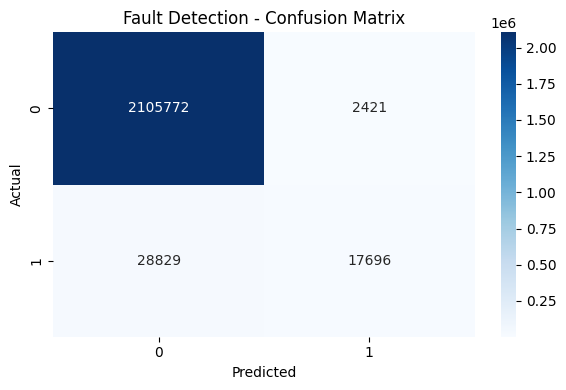

Filtering instances for fault classification...
Training Random Forest for fault classification (on 186101 fault instances)...


RF Fault Classification:   0%|          | 0/100 [00:00<?, ?it/s]

building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100


[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    2.0s


building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81 of 100
building tree 82 of 100
building tree 83 of 100
building tree 84

[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    4.9s finished
RF Fault Classification: 100%|██████████| 100/100 [00:04<00:00, 20.23it/s]

building tree 97 of 100
building tree 98 of 100
building tree 99 of 100
building tree 100 of 100
Predicting fault types...



[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this 

Fault Classification - Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2421
           1       0.98      1.00      0.99      2862
           2       0.90      1.00      0.95       102
           3       0.86      1.00      0.93     14732

    accuracy                           0.88     20117
   macro avg       0.69      0.75      0.72     20117
weighted avg       0.78      0.88      0.82     20117



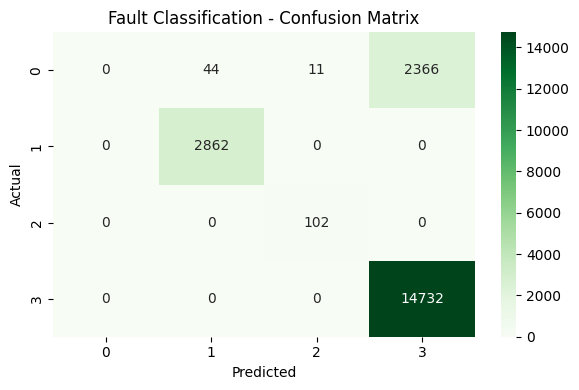

In [ ]:
# 2. Random Forest Fault Prediction
rf_fault, rf_fault_type, X_test, X_test_scaled, X_test_faults, X_test_faults_scaled = random_forest_prediction(
    X_train, X_test, X_train_scaled, X_test_scaled, y_train_fault, y_test_fault, y_train_fault_type, y_test_fault_type, features)

In [ ]:
# 3. SHAP Root Cause Analysis
# SHAP analysis for fault detection
print("\nPerforming SHAP analysis for fault detection...")
shap_root_cause_analysis(rf_fault, X_test_scaled, features,class_names=['No Fault', 'Fault'])
# SHAP analysis for fault classification if model exists
if rf_fault_type is not None and X_test_faults_scaled is not None:
    print("\nPerforming SHAP analysis for fault classification...")
    class_names = [fault_type_mapping[i] for i in range(1, 4)]
    shap_root_cause_analysis(rf_fault_type, X_test_faults_scaled, features, class_names=class_names)